In [1]:
import os
import glob
import numpy as np
import xarray as xr
import nc_time_axis

In [2]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import pandas as pd
import requests
import xarray as xr

import earthaccess

CMR_COLLECTIONS = "https://cmr.earthdata.nasa.gov/search/collections.json"
CMR_GRANULES = "https://cmr.earthdata.nasa.gov/search/granules.json"


def cmr_search(url: str, **params):
    # Return the list of CMR entries for a JSON search response.
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    payload = response.json()
    return payload["feed"]["entry"]


def maybe_call(obj, attr_name: str):
    # Support both property- and method-style earthaccess APIs.
    value = getattr(obj, attr_name)
    return value() if callable(value) else value


def collection_table(entries):
    rows = []
    for c in entries:
        rows.append(
            {
                "short_name": c.get("short_name"),
                "version": c.get("version_id"),
                "title": c.get("dataset_id"),
                "archive_center": c.get("archive_center"),
                "concept_id": c.get("id"),
                "time_start": c.get("time_start"),
                "time_end": c.get("time_end"),
            }
        )
    return pd.DataFrame(rows)


def first_data_link(entry: dict):
    # Return the first likely data link from a CMR granule entry.
    for link in entry.get("links", []):
        href = link.get("href")
        rel = link.get("rel", "")
        if not href:
            continue
        if link.get("inherited") is True:
            continue
        if "data#" in rel or "download#" in rel:
            return href
    return None


def granule_table(entries):
    rows = []
    for g in entries:
        rows.append(
            {
                "producer_granule_id": g.get("producer_granule_id"),
                "time_start": g.get("time_start"),
                "time_end": g.get("time_end"),
                "updated": g.get("updated"),
                "granule_size_MB": g.get("granule_size"),
                "sample_data_link": first_data_link(g),
            }
        )
    return pd.DataFrame(rows)


def link_or_none(granule, access="external"):
    try:
        links = granule.data_links(access=access)
        return links[0] if links else None
    except Exception:
        return None

# ECCOv4

In [3]:
broad_collections = cmr_search(
    CMR_COLLECTIONS,
    keyword="ecco",
    page_size=50,
)

collection_table(broad_collections)

,short_name,version,title,archive_center,concept_id,time_start,time_end
0,ECCO_L4_TEMP_SALINITY_LLC0090GRID_MONTHLY_V4R4,V4r4,ECCO Ocean Temperature and Salinity - Monthly ...,NASA/JPL/PODAAC,C1991543728-POCLOUD,1992-01-01T00:00:00.000Z,2018-01-01T00:00:00.000Z
1,ECCO_L4_HEAT_FLUX_05DEG_DAILY_V4R4,V4r4,ECCO Ocean and Sea-Ice Surface Heat Fluxes - D...,NASA/JPL/PODAAC,C1990404788-POCLOUD,1992-01-01T00:00:00.000Z,2018-01-01T00:00:00.000Z
2,ECCO_L4_MIXED_LAYER_DEPTH_05DEG_DAILY_V4R4,V4r4,ECCO Ocean Mixed Layer Depth - Daily Mean 0.5 ...,NASA/JPL/PODAAC,C1990404810-POCLOUD,1992-01-01T00:00:00.000Z,2018-01-01T00:00:00.000Z
3,ECCO_L4_OCEAN_VEL_05DEG_DAILY_V4R4,V4r4,ECCO Ocean Velocity - Daily Mean 0.5 Degree (V...,NASA/JPL/PODAAC,C1990404811-POCLOUD,1992-01-01T00:00:00.000Z,2018-01-01T00:00:00.000Z
4,ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4,V4r4,ECCO Ocean Temperature and Salinity - Daily Me...,NASA/JPL/PODAAC,C1990404821-POCLOUD,1992-01-01T00:00:00.000Z,2018-01-01T00:00:00.000Z
5,SASSIE_ECCO_L4_ATM_STATE_LLC1080GRID_DAILY_V1R1,V1R1,"SASSIE ECCO Atmosphere Surface Temperature, Hu...",NASA/JPL/PODAAC,C3675383068-POCLOUD,2014-01-15T00:00:00.000Z,2021-02-08T00:00:00.000Z
6,SASSIE_ECCO_L4_DENS_PRESS_LLC1080GRID_DAILY_V1R1,V1R1,SASSIE ECCO Ocean Density and Hydrostatic Pres...,NASA/JPL/PODAAC,C3675524854-POCLOUD,2014-01-15T00:00:00.000Z,2021-02-08T00:00:00.000Z
7,SASSIE_ECCO_L4_FRESH_FLUX_LLC1080GRID_DAILY_V1R1,V1R1,SASSIE ECCO Ocean and Sea-Ice Surface Freshwat...,NASA/JPL/PODAAC,C3874470970-POCLOUD,2014-01-15T00:00:00.000Z,2021-02-08T00:00:00.000Z
8,SASSIE_ECCO_L4_GEOMETRY_LLC1080GRID_V1R1,V1R1,SASSIE ECCO Geometry Parameters - llc1080 Grid...,NASA/JPL/PODAAC,C3706337498-POCLOUD,2014-01-15T00:00:00.000Z,2021-02-08T00:00:00.000Z
9,SASSIE_ECCO_L4_HEAT_FLUX_LLC1080GRID_DAILY_V1R1,V1R1,SASSIE ECCO Ocean and Sea-Ice Surface Heat Flu...,NASA/JPL/PODAAC,C3874536221-POCLOUD,2014-01-15T00:00:00.000Z,2021-02-08T00:00:00.000Z


## CMR search

In [4]:
short_name = "ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4"
temp_ecco4_entries = cmr_search(
    CMR_COLLECTIONS,
    short_name=short_name,
    page_size=5,
)

temp_ecco4_collection = temp_ecco4_entries[0]
temp_ecco4_collection

{'processing_level_id': '4',
 'cloud_hosted': True,
 'boxes': ['-90 -180 90 180'],
 'has_combine': False,
 'time_start': '1992-01-01T00:00:00.000Z',
 'version_id': 'V4r4',
 'dataset_id': 'ECCO Ocean Temperature and Salinity - Daily Mean 0.5 Degree (Version 4 Release 4)',
 'entry_id': 'ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4_V4r4',
 'has_spatial_subsetting': False,
 'has_transforms': False,
 'associations': {'variables': ['V2112013729-POCLOUD',
   'V1994907639-POCLOUD',
   'V2112013727-POCLOUD',
   'V2112013734-POCLOUD',
   'V2112013725-POCLOUD',
   'V1994943196-POCLOUD',
   'V2112013741-POCLOUD',
   'V1994907641-POCLOUD',
   'V2112013737-POCLOUD',
   'V2112013739-POCLOUD'],
  'services': ['S2874702816-XYZ_PROV'],
  'tools': ['TL2108419875-POCLOUD'],
  'citations': ['CIT3804299501-ESDIS',
   'CIT3804162922-ESDIS',
   'CIT3804326669-ESDIS']},
 'has_variables': True,
 'data_center': 'POCLOUD',
 'short_name': 'ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4',
 'organizations': ['NASA/JPL/PODAAC'],
 

In [5]:
temp_ecco4_granule_entries = cmr_search(
    CMR_GRANULES,
    collection_concept_id=temp_ecco4_collection["id"],
    temporal="2017-01-01T00:00:00Z,2017-12-31T00:00:00.00Z",
    page_size=10,
)

granule_table(temp_ecco4_granule_entries)

,producer_granule_id,time_start,time_end,updated,granule_size_MB,sample_data_link
0,None,2016-12-31T00:00:00.000Z,2017-01-01T00:00:00.000Z,2021-04-13T00:25:49.990Z,19.62463665008545,https://archive.podaac.earthdata.nasa.gov/poda...
1,None,2017-01-01T00:00:00.000Z,2017-01-02T00:00:00.000Z,2021-04-13T00:26:07.467Z,1.9550323486328125E-4,https://archive.podaac.earthdata.nasa.gov/poda...
2,None,2017-01-02T00:00:00.000Z,2017-01-03T00:00:00.000Z,2021-04-13T00:25:17.415Z,19.62383460998535,https://archive.podaac.earthdata.nasa.gov/poda...
3,None,2017-01-03T00:00:00.000Z,2017-01-04T00:00:00.000Z,2021-04-13T00:27:21.655Z,19.623977661132812,https://archive.podaac.earthdata.nasa.gov/poda...
4,None,2017-01-04T00:00:00.000Z,2017-01-05T00:00:00.000Z,2021-04-13T00:27:59.432Z,19.624380111694336,https://archive.podaac.earthdata.nasa.gov/poda...
5,None,2017-01-05T00:00:00.000Z,2017-01-06T00:00:00.000Z,2021-04-13T00:26:09.426Z,1.9550323486328125E-4,https://archive.podaac.earthdata.nasa.gov/poda...
6,None,2017-01-06T00:00:00.000Z,2017-01-07T00:00:00.000Z,2021-04-13T00:28:00.982Z,1.9550323486328125E-4,https://archive.podaac.earthdata.nasa.gov/poda...
7,None,2017-01-07T00:00:00.000Z,2017-01-08T00:00:00.000Z,2021-04-13T00:25:19.832Z,19.620189666748047,https://archive.podaac.earthdata.nasa.gov/poda...
8,None,2017-01-08T00:00:00.000Z,2017-01-09T00:00:00.000Z,2021-04-13T00:28:01.356Z,1.9550323486328125E-4,https://archive.podaac.earthdata.nasa.gov/poda...
9,None,2017-01-09T00:00:00.000Z,2017-01-10T00:00:00.000Z,2021-04-13T00:27:57.899Z,1.9550323486328125E-4,https://archive.podaac.earthdata.nasa.gov/poda...


In [6]:
temp_ecco4_dataset = earthaccess.search_datasets(
    short_name=short_name,
    cloud_hosted=True,
)[0]

pprint(temp_ecco4_dataset.summary())

{'cloud-info': {'Region': 'us-west-2',
                'S3BucketAndObjectPrefixNames': ['podaac-ops-cumulus-protected/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4/',
                                                 'podaac-ops-cumulus-public/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4/'],
                'S3CredentialsAPIDocumentationURL': 'https://archive.podaac.earthdata.nasa.gov/s3credentialsREADME',
                'S3CredentialsAPIEndpoint': 'https://archive.podaac.earthdata.nasa.gov/s3credentials'},
 'concept-id': 'C1990404821-POCLOUD',
 'file-type': "[{'Format': 'netCDF-4', 'FormatType': 'Native'}]",
 'get-data': ['https://search.earthdata.nasa.gov/search/granules?p=C1990404821-POCLOUD',
              'https://cmr.earthdata.nasa.gov/virtual-directory/collections/C1990404821-POCLOUD/temporal',
              'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-public/virtual_collections/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4_virtual_https.json'

In [ ]:
print("Concept ID:", maybe_call(temp_ecco4_dataset, "concept_id"))
print("Version:", maybe_call(temp_ecco4_dataset, "version"))
print("Landing page:", maybe_call(temp_ecco4_dataset, "landing_page"))

try:
    print("Services:")
    pprint(maybe_call(temp_ecco4_dataset, "services"))
except Exception as exc:
    print("Could not list services:", exc)

In [8]:
auth = earthaccess.login()
auth

In [9]:
temp_ecco4_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2017-01-01", "2017-12-31"),
)

len(temp_ecco4_results), temp_ecco4_results[0]

(366,
 Collection: {'Version': 'V4r4', 'ShortName': 'ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180, 'SouthBoundingCoordinate': -90, 'EastBoundingCoordinate': 180, 'NorthBoundingCoordinate': 90}]}}}
 Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2017-01-01T00:00:00.000Z', 'BeginningDateTime': '2016-12-31T00:00:00.000Z'}}
 Size(MB): 19.624832153320312
 Data: ['https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4/OCEAN_TEMPERATURE_SALINITY_day_mean_2016-12-31_ECCO_V4r4_latlon_0p50deg.nc'])

In [10]:
pd.DataFrame(
    {
        "granule": [repr(g) for g in temp_ecco4_results],
        "size_MB": [g.size() for g in temp_ecco4_results],
        "https_link": [link_or_none(g, access="external") for g in temp_ecco4_results],
    }
)

,granule,size_MB,https_link
0,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.624832,https://archive.podaac.earthdata.nasa.gov/poda...
1,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.623074,https://archive.podaac.earthdata.nasa.gov/poda...
2,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.624030,https://archive.podaac.earthdata.nasa.gov/poda...
3,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.624173,https://archive.podaac.earthdata.nasa.gov/poda...
4,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.624576,https://archive.podaac.earthdata.nasa.gov/poda...
...,...,...,...
361,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.610826,https://archive.podaac.earthdata.nasa.gov/poda...
362,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.609307,https://archive.podaac.earthdata.nasa.gov/poda...
363,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.609567,https://archive.podaac.earthdata.nasa.gov/poda...
364,"Collection: {'Version': 'V4r4', 'ShortName': '...",19.604563,https://archive.podaac.earthdata.nasa.gov/poda...


In [11]:
print("External HTTPS link:")
print(link_or_none(temp_ecco4_results[0], access="external"))

print("\nDirect S3 link (useful in us-west-2):")
print(link_or_none(temp_ecco4_results[0], access="direct"))

External HTTPS link:
https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4/OCEAN_TEMPERATURE_SALINITY_day_mean_2016-12-31_ECCO_V4r4_latlon_0p50deg.nc

Direct S3 link (useful in us-west-2):
s3://podaac-ops-cumulus-protected/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4/OCEAN_TEMPERATURE_SALINITY_day_mean_2016-12-31_ECCO_V4r4_latlon_0p50deg.nc


In [12]:
opened = earthaccess.open(temp_ecco4_results[:3])

temp_ecco4_datasets = [xr.open_dataset(obj) for obj in opened]
temp_ecco4_ds = xr.concat(temp_ecco4_datasets, dim="time").sortby("time")

temp_ecco4_ds

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

<xarray.Dataset> Size: 311MB
Dimensions:         (time: 3, Z: 50, latitude: 360, longitude: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 24B 2016-12-31T12:00:00 ... 2017-01...
  * Z               (Z) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
  * latitude        (latitude) float32 1kB -89.75 -89.25 -88.75 ... 89.25 89.75
  * longitude       (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 48B 2016-12-31 ... 2017-01-03
    latitude_bnds   (latitude, nv) float32 3kB -90.0 -89.5 -89.5 ... 89.5 90.0
    longitude_bnds  (longitude, nv) float32 6kB -180.0 -179.5 ... 179.5 180.0
    Z_bnds          (Z, nv) float32 400B 0.0 -10.0 ... -5.678e+03 -6.134e+03
Dimensions without coordinates: nv
Data variables:
    THETA           (time, Z, latitude, longitude) float32 156MB nan nan ... nan
    SALT            (time, Z, latitude, longitude) float32 156MB nan nan ... nan
Attributes: (12/62)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on a regular lat-lon gri...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2017-01-01T00:00:00
    time_coverage_resolution:        P1D
    time_coverage_start:             2016-12-31T00:00:00
    title:                           ECCO Ocean Temperature and Salinity - Da...
    uuid:                            1581c426-4128-11eb-8800-0cc47a3f575f

In [27]:
list(temp_ecco4_ds.data_vars)

['THETA', 'SALT']

## From ECCO python tutorial

In [13]:
# doesnt work with SW3 authentication. 

# Observations

In [3]:
auth = earthaccess.login()

In [4]:
broad_collections = cmr_search(
    CMR_COLLECTIONS,
    keyword="sea surface temperature",
    page_size=20,
)

collection_table(broad_collections)

,short_name,version,title,archive_center,concept_id,time_start,time_end
0,OSTIA-UKMO-L4-GLOB-REP-v2.0,2.0,GHRSST Level 4 OSTIA Global Historical Reproce...,NASA/JPL/PODAAC,C2586786218-POCLOUD,1982-01-01T00:00:00.000Z,2024-01-01T00:00:00.000Z
1,EO:EUM:DAT:SENTINEL-3:SL_2_WST___NRT,2017-07-05,SLSTR Sea Surface Temperatures (SST) in NRT - ...,None,C1588876556-EUMETSAT,2017-07-05T00:00:00.000Z,None
2,EO:EUM:DAT:SENTINEL-3:SL_2_WST___NTC,2017-07-05,SLSTR Sea Surface Temperatures (SST) in NTC - ...,None,C1588876559-EUMETSAT,2017-07-05T00:00:00.000Z,None
3,MUR-JPL-L4-GLOB-v4.1,4.1,GHRSST Level 4 MUR Global Foundation Sea Surfa...,NASA/JPL/PODAAC,C1996881146-POCLOUD,2002-05-31T21:00:00.000Z,None
4,MUR25-JPL-L4-GLOB-v04.2,4.2,GHRSST Level 4 MUR 0.25deg Global Foundation S...,NASA/JPL/PODAAC,C2036880657-POCLOUD,2002-08-31T21:00:00.000Z,None
5,OSTIA-UKMO-L4-GLOB-v2.0,2.0,GHRSST Level 4 OSTIA Global Foundation Sea Sur...,NASA/JPL/PODAAC,C2036877535-POCLOUD,2006-12-31T00:00:00.000Z,None
6,AVHRR_OI-NCEI-L4-GLOB-v2.1,2.1,GHRSST Level 4 AVHRR_OI Global Blended Sea Sur...,NASA/JPL/PODAAC,C2036881712-POCLOUD,2016-01-01T00:00:00.000Z,None
7,CMC0.1deg-CMC-L4-GLOB-v3.0,3.0,GHRSST Level 4 CMC0.1deg Global Foundation Sea...,NASA/JPL/PODAAC,C2036881720-POCLOUD,2016-01-01T00:00:00.000Z,None
8,GAMSSA_28km-ABOM-L4-GLOB-v01,1.0,GHRSST Level 4 GAMSSA_28km Global Foundation S...,NASA/JPL/PODAAC,C2036881735-POCLOUD,2008-07-23T00:00:00.000Z,None
9,G18-ABI-L3C-ACSPO-v2.90,2.90,GHRSST L3C NOAA/ACSPO GOES-18/ABI West America...,NASA/JPL/PODAAC,C2731041317-POCLOUD,2022-06-07T00:00:00.000Z,None


## SST

In [5]:
chunks = {'time':1}

### GHRSST L4 MUR 0.25deg Global Foundation Sea Surface Temperature Analysis (v4.2)
0.25deg, daily, 2002-present, combines many different sensors (AMSR, MODIS, AVHRR, WindSat + in situ) -> probably our best overall comparison

https://www.earthdata.nasa.gov/data/catalog/pocloud-mur25-jpl-l4-glob-v04.2-4.2

In [11]:
short_name = "MUR25-JPL-L4-GLOB-v04.2"
sst_mur25_entries = cmr_search(
    CMR_COLLECTIONS,
    short_name=short_name,
    page_size=5,
)

sst_mur25_collection = sst_mur25_entries[0]
sst_mur25_collection

{'processing_level_id': '4',
 'cloud_hosted': True,
 'boxes': ['-90 -180 90 180'],
 'has_combine': False,
 'time_start': '2002-08-31T21:00:00.000Z',
 'version_id': '4.2',
 'updated': '2019-08-09T19:47:48.185Z',
 'dataset_id': 'GHRSST Level 4 MUR 0.25deg Global Foundation Sea Surface Temperature Analysis (v4.2)',
 'entry_id': 'MUR25-JPL-L4-GLOB-v04.2_4.2',
 'has_spatial_subsetting': True,
 'has_transforms': False,
 'associations': {'variables': ['V2089830953-POCLOUD',
   'V2089830962-POCLOUD',
   'V2089830949-POCLOUD',
   'V2089830964-POCLOUD',
   'V2089830960-POCLOUD',
   'V2112015416-POCLOUD',
   'V2089830957-POCLOUD',
   'V2089830947-POCLOUD'],
  'services': ['S2164732315-XYZ_PROV',
   'S2874702816-XYZ_PROV',
   'S3616918458-LARC_CLOUD',
   'S3177988677-POCLOUD'],
  'tools': ['TL2245207664-POCLOUD', 'TL2108419875-POCLOUD'],
  'citations': ['CIT3804254849-ESDIS',
   'CIT3804127322-ESDIS',
   'CIT3804154045-ESDIS',
   'CIT3804295951-ESDIS',
   'CIT3804178271-ESDIS',
   'CIT3804204870-E

In [12]:
sst_mur25_dataset = earthaccess.search_datasets(
    short_name=short_name,
    cloud_hosted=True,
)[0]

pprint(sst_mur25_dataset.summary())

sst_mur25_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2018-01-01", "2018-01-05"),
)

len(sst_mur25_results), sst_mur25_results[0]

opened = earthaccess.open(sst_mur25_results)

sst_mur25_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',parallel=True)
sst_mur25_ds

{'cloud-info': {'Region': 'us-west-2',
                'S3BucketAndObjectPrefixNames': ['podaac-ops-cumulus-public/MUR25-JPL-L4-GLOB-v04.2/',
                                                 'podaac-ops-cumulus-protected/MUR25-JPL-L4-GLOB-v04.2/'],
                'S3CredentialsAPIDocumentationURL': 'https://archive.podaac.earthdata.nasa.gov/s3credentialsREADME',
                'S3CredentialsAPIEndpoint': 'https://archive.podaac.earthdata.nasa.gov/s3credentials'},
 'concept-id': 'C2036880657-POCLOUD',
 'file-type': "[{'Format': 'netCDF-4', 'FormatType': 'Native', "
              "'FormatDescription': 'netCDF', 'AverageFileSize': 2.0, "
              "'AverageFileSizeUnit': 'MB', "
              "'TotalCollectionFileSizeBeginDate': "
              "'2002-06-01T00:00:00.000Z'}]",
 'get-data': ['https://cmr.earthdata.nasa.gov/virtual-directory/collections/C2036880657-POCLOUD',
              'https://search.earthdata.nasa.gov/search/granules?p=C2036880657-POCLOUD',
              'https://

QUEUEING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/6 [00:00<?, ?it/s]

<xarray.Dataset> Size: 224MB
Dimensions:           (time: 6, lat: 720, lon: 1440)
Coordinates:
  * time              (time) datetime64[ns] 48B 2018-01-01T09:00:00 ... 2018-...
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    analysed_sst      (time, lat, lon) float64 50MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    analysis_error    (time, lat, lon) float64 50MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    mask              (time, lat, lon) float32 25MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float64 50MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sst_anomaly       (time, lat, lon) float64 50MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/54)
    Conventions:                CF-1.7, ACDD-1.3
    title:                      Daily 0.25-degree MUR SST, Final product
    summary:                    A low-resolution version of the MUR SST analy...
    keywords:                   Oceans > Ocean Temperature > Sea Surface Temp...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    ...                         ...
    publisher_name:             GHRSST Project Office
    publisher_url:              https://www.ghrsst.org
    publisher_email:            gpc@ghrsst.org
    file_quality_level:         3
    metadata_link:              http://podaac.jpl.nasa.gov/ws/metadata/datase...
    acknowledgment:             Please acknowledge the use of these data with...

### GHRSST L4 MW_OI Global Foundation Sea Surface Temperature Analysis (v5.1)
0.25deg, daily, microwave + IR blended (good all-weather coverage) -> good coverage may be important for heat transport estimates

https://podaac.jpl.nasa.gov/dataset/MW_OI-REMSS-L4-GLOB-v5.1

In [52]:
short_name = "MW_OI-REMSS-L4-GLOB-v5.1"
sst_mwoi_entries = cmr_search(
    CMR_COLLECTIONS,
    short_name=short_name,
    page_size=5,
)

sst_mwoi_collection = sst_mwoi_entries[0]
sst_mwoi_collection

In [ ]:
sst_mwoi_dataset = earthaccess.search_datasets(
    short_name=short_name,
    cloud_hosted=True,
)[0]

pprint(sst_mwoi_dataset.summary())

sst_mwoi_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2018-01-01", "2018-12-31"),
)

opened = earthaccess.open(sst_mwoi_results)

sst_mwoi_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',parallel=True)
sst_mwoi_ds

### GHRSST L4 AVHRR_OI Global Blended Sea Surface Temperature Analysis (v2.0)
0.25deg, daily, mainly AVHRR from NOAA NCEI

https://podaac.jpl.nasa.gov/dataset/AVHRR_OI-NCEI-L4-GLOB-v2.0

In [54]:
short_name = "AVHRR_OI-NCEI-L4-GLOB-v2.0"
sst_oincei_entries = cmr_search(
    CMR_COLLECTIONS,
    short_name=short_name,
    page_size=5,
)

sst_oincei_collection = sst_oincei_entries[0]
sst_oincei_collection

In [ ]:
sst_oincei_dataset = earthaccess.search_datasets(
    short_name=short_name,
    cloud_hosted=True,
)[0]

pprint(sst_oincei_dataset.summary())

sst_oincei_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2018-01-01", "2018-12-31"),
)

opened = earthaccess.open(sst_oincei_results)

sst_oincei_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',parallel=True)
sst_oincei_ds

### GHRSST L4 OSTIA Global Foundation Sea Surface Temperature Analysis (v2.0)
Even higher resolution from UK Met Office at 0.05deg -> may be key for eddy transports

https://podaac.jpl.nasa.gov/dataset/ostia-ukmo-l4-glob-v2.0

In [ ]:
short_name = "ostia-ukmo-l4-glob-v2.0"
sst_ostia_entries = cmr_search(
    CMR_COLLECTIONS,
    short_name=short_name,
    page_size=5,
)

sst_ostia_collection = sst_ostia_entries[0]
sst_ostia_collection

In [30]:
sst_ostia_dataset = earthaccess.search_datasets(
    short_name=short_name,
    cloud_hosted=True,
)[0]

pprint(sst_ostia_dataset.summary())

sst_ostia_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2018-01-01", "2018-12-31"),
)

opened = earthaccess.open(sst_ostia_results)

sst_ostia_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',parallel=True)
sst_ostia_ds

{'cloud-info': {'Region': 'us-west-2',
                'S3BucketAndObjectPrefixNames': ['podaac-ops-cumulus-protected/OSTIA-UKMO-L4-GLOB-v2.0/',
                                                 'podaac-ops-cumulus-public/OSTIA-UKMO-L4-GLOB-v2.0/'],
                'S3CredentialsAPIDocumentationURL': 'https://archive.podaac.earthdata.nasa.gov/s3credentialsREADME',
                'S3CredentialsAPIEndpoint': 'https://archive.podaac.earthdata.nasa.gov/s3credentials'},
 'concept-id': 'C2036877535-POCLOUD',
 'file-type': "[{'Format': 'netCDF-4', 'FormatType': 'Native'}]",
 'get-data': ['https://cmr.earthdata.nasa.gov/virtual-directory/collections/C2036877535-POCLOUD',
              'https://search.earthdata.nasa.gov/search/granules?p=C2036877535-POCLOUD',
              'https://github.com/podaac/data-subscriber'],
 'short-name': 'OSTIA-UKMO-L4-GLOB-v2.0',
 'version': '2.0'}


## SSH

In [6]:
broad_collections = cmr_search(
    CMR_COLLECTIONS,
    # keyword="sea surface height",
    keyword="sea surface height",
    page_size=20,
)

collection_table(broad_collections)

,short_name,version,title,archive_center,concept_id,time_start,time_end
0,SWOT_L2_LR_SSH_2.0,2.0,SWOT Level 2 KaRIn Low Rate Sea Surface Height...,NASA/JPL/PODAAC,C2799438306-POCLOUD,2022-12-16T00:00:00.000Z,None
1,SWOT_L2_LR_SSH_D,D,SWOT Level 2 KaRIn Low Rate Sea Surface Height...,NASA/JPL/PODAAC,C3233945000-POCLOUD,2022-12-16T00:00:00.000Z,None
2,NASA_SSH_GMSL_INDICATOR,1,NASA-SSH Global Mean Sea Level from Simple Gri...,NASA/JPL/PODAAC,C3478934705-POCLOUD,1993-01-04T00:00:00.000Z,None
3,NEUROST_SSH-SST_L4_V2024.0,2024.0,Daily NeurOST L4 Sea Surface Height and Surfac...,NASA/JPL/PODAAC,C3085229833-POCLOUD,2010-01-01T00:00:00.000Z,None
4,SEA_SURFACE_HEIGHT_ALT_GRIDS_L4_2SATS_5DAY_6TH...,2205,MEaSUREs Gridded Sea Surface Height Anomalies ...,NASA/JPL/PODAAC,C2270392799-POCLOUD,1992-10-01T23:46:00.000Z,None
5,ATL21,004,ATLAS/ICESat-2 L3B Daily and Monthly Gridded P...,NASA NSIDC DAAC,C3826284331-NSIDC_CPRD,2018-10-14T00:00:00.000Z,None
6,ALTIKA_SARAL_L2_OST_XOGDR,f,SARAL Near-Real-Time Value-added Operational G...,NASA/JPL/PODAAC,C2251465126-POCLOUD,2020-03-18T00:00:00.000Z,None
7,NASA_SSH_REF_ALONGTRACK_V1,1,NASA-SSH Along-Track Sea Surface Height from S...,None,C3309450672-POCLOUD,1992-10-25T00:00:00.000Z,None
8,NASA_SSH_ENSO_INDICATOR,1,NASA-SSH ENSO Sea Surface Height Indicator,NASA/JPL/PODAAC,C3473420592-POCLOUD,1993-01-04T00:00:00.000Z,None
9,NASA_SSH_IOD_INDICATOR,1,NASA-SSH IOD Sea Surface Height Indicator,NASA/JPL/PODAAC,C3478941029-POCLOUD,1993-01-04T00:00:00.000Z,None


### AVISO / DUACS L4 Dynamic Topography
0.25deg, daily, Jason, Sentinal, etc. nadir altimetry data product, baseline for all geostrophic estimates

NOTE: This is NOT hosted on NASA-PODAAC; only the 1deg, monthly product is there for CMIP5 purposes. The full dataset is only hosted on Copernicus Marine (EU). We will not use it in this notebook.

In [ ]:
ssh_aviso_entries = cmr_search(
    CMR_COLLECTIONS,
    short_name="AVISO_L4_DYN_TOPO_1DEG_1MO",
    page_size=5,
)

ssh_aviso_collection = ssh_aviso_entries[0]
ssh_aviso_collection

### Daily NeurOST L4 Sea Surface Height and Surface Geostrophic Currents

Neural network-mapped SSH and current which combines SSH with SST for improved surface flow -> most likely very useful since combines SST and SSH (though neural network mapped...)

https://podaac.jpl.nasa.gov/dataset/NEUROST_SSH-SST_L4_V2024.0

In [8]:
short_name = "NEUROST_SSH-SST_L4_V2024.0"
ssh_neuro_entries = cmr_search(
    CMR_COLLECTIONS,
    short_name=short_name,
    page_size=5,
)

ssh_neuro_collection = ssh_neuro_entries[0]
ssh_neuro_collection

{'processing_level_id': '4',
 'cloud_hosted': True,
 'boxes': ['-70 -180 79.9 180'],
 'has_combine': False,
 'time_start': '2010-01-01T00:00:00.000Z',
 'version_id': '2024.0',
 'dataset_id': 'Daily NeurOST L4 Sea Surface Height and Surface Geostrophic Currents',
 'entry_id': 'NEUROST_SSH-SST_L4_V2024.0_2024.0',
 'has_spatial_subsetting': True,
 'has_transforms': False,
 'associations': {'variables': ['V3185983070-POCLOUD',
   'V3185983076-POCLOUD',
   'V3185983058-POCLOUD',
   'V3185983067-POCLOUD',
   'V3185983093-POCLOUD',
   'V3185983096-POCLOUD',
   'V3185983078-POCLOUD',
   'V3185983073-POCLOUD',
   'V3185983081-POCLOUD',
   'V3185983087-POCLOUD',
   'V3185983083-POCLOUD',
   'V3185983041-POCLOUD',
   'V3185983052-POCLOUD'],
  'services': ['S2164732315-XYZ_PROV', 'S2874702816-XYZ_PROV'],
  'tools': ['TL2108419875-POCLOUD'],
  'citations': ['CIT4106692522-ESDIS',
   'CIT3857573761-ESDIS',
   'CIT3857566649-ESDIS',
   'CIT3804319507-ESDIS',
   'CIT3804308064-ESDIS',
   'CIT410669391

In [9]:
ssh_neuro_dataset = earthaccess.search_datasets(
    short_name=short_name,
    cloud_hosted=True,
)[0]

pprint(ssh_neuro_dataset.summary())

ssh_neuro_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2018-01-01", "2018-01-04"),
)

opened = earthaccess.open(ssh_neuro_results)
ssh_neuro_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',parallel=True)
ssh_neuro_ds

{'cloud-info': {'Region': 'us-west-2',
                'S3BucketAndObjectPrefixNames': ['podaac-ops-cumulus-public/NEUROST_SSH-SST_L4_V2024.0/',
                                                 'podaac-ops-cumulus-protected/NEUROST_SSH-SST_L4_V2024.0/'],
                'S3CredentialsAPIDocumentationURL': 'https://archive.podaac.earthdata.nasa.gov/s3credentialsREADME',
                'S3CredentialsAPIEndpoint': 'https://archive.podaac.earthdata.nasa.gov/s3credentials'},
 'concept-id': 'C3085229833-POCLOUD',
 'file-type': "[{'Format': 'netCDF-4', 'FormatType': 'Native', "
              "'AverageFileSize': 9.7, 'AverageFileSizeUnit': 'MB'}]",
 'get-data': ['https://cmr.earthdata.nasa.gov/virtual-directory/collections/C3085229833-POCLOUD',
              'https://search.earthdata.nasa.gov/search/granules?p=C3085229833-POCLOUD',
              'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-public/virtual_collections/NEUROST_SSH-SST_L4_V2024.0/NEUROST_SSH-SST_L4_V2024.0_virtua

QUEUEING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_4637/290428455.py:15: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ssh_neuro_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',


<xarray.Dataset> Size: 972MB
Dimensions:                 (latitude: 1500, longitude: 3600, time: 5)
Coordinates:
  * latitude                (latitude) float64 12kB -70.0 -69.9 ... 79.8 79.9
  * longitude               (longitude) float64 29kB 0.1 0.2 0.3 ... 359.9 360.0
  * time                    (time) datetime64[ns] 40B 2017-12-31 ... 2018-01-04
    Lambert_Azimuthal_Grid  int32 4B -2147483647
Data variables:
    sla                     (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    adt                     (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    ugosa                   (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    vgosa                   (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    sn                      (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    ss                      (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    zeta                    (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    ugos                    (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    vgos                    (latitude, longitude, time) float32 108MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
Attributes: (12/37)
    title:                      Daily NeurOST (SSH-SST) Sea Surface Height an...
    summary:                    A mapped level 4 sea surface height analysis ...
    Conventions:                CF-1.10
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    keywords:                   Oceans > Sea Surface Topography > Sea Surface...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    ...                         ...
    creator_url:                http://podaac.jpl.nasa.gov
    publisher_name:             JPL PO.DAAC
    publisher_url:              http://podaac.jpl.nasa.gov
    date_created:               2024-05-06T18:53:05.720120
    references:                 https://doi.org/10.31223/X5W676 and https://d...
    comment:                    NeurOST = Neural Ocean Surface Topography. Ne...

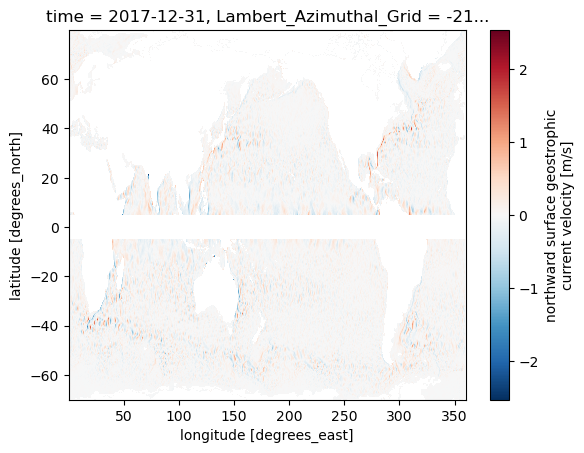

In [10]:
ssh_neuro_ds.vgos.isel(time=0).plot()